In [227]:
import cv2
import matplotlib.pyplot as plt
import numpy as np

(np.float64(-0.5), np.float64(719.5), np.float64(719.5), np.float64(-0.5))

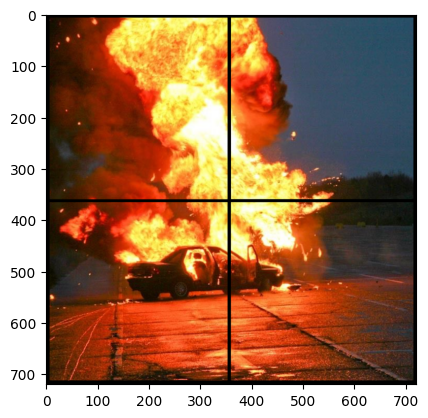

In [228]:
meledak = plt.imread('Meledak.png')
plt.imshow(meledak)
plt.axis('on')

(np.float64(-0.5), np.float64(349.5), np.float64(339.5), np.float64(-0.5))

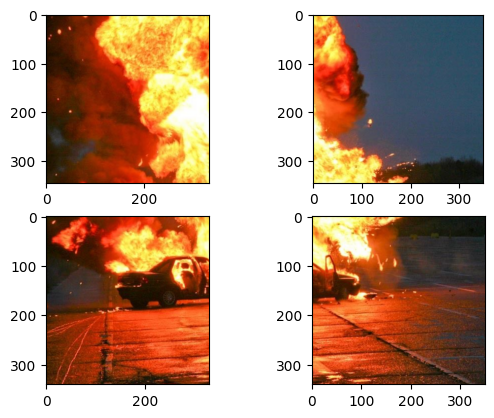

In [229]:
meledak1 = meledak[15:360,15:350]
meledak2 = meledak[15:360,365:715]
meledak3 = meledak[370:710,15:345]
meledak4 = meledak[370:710,365:715]

subplot = plt.subplot(2, 2, 1)
plt.imshow(meledak1)
plt.axis('on')

subplot = plt.subplot(2, 2, 2)
plt.imshow(meledak2)
plt.axis('on')

subplot = plt.subplot(2,2, 3)
plt.imshow(meledak3)
plt.axis('on')

subplot = plt.subplot(2, 2,4)
plt.imshow(meledak4)
plt.axis('on')



In [230]:
def merge_image(citra1, citra2, orientation='H'): 
    if orientation == 'H':   
        tinggi = max(citra1.shape[0], citra2.shape[0]) 
        lebar_total = citra1.shape[1] + citra2.shape[1] 
        
        if len(citra1.shape) == 2: 
            gabungan = np.zeros((tinggi, lebar_total), dtype=citra1.dtype) 
        else: 
            gabungan = np.zeros((tinggi, lebar_total, citra1.shape[2]), dtype=citra1.dtype) 
        
        gabungan[0:citra1.shape[0], 0:citra1.shape[1]] = citra1 
        gabungan[0:citra2.shape[0], citra1.shape[1]:citra1.shape[1]+citra2.shape[1]] = citra2 
        
    else:   
        tinggi_total = citra1.shape[0] + citra2.shape[0] 
        lebar = max(citra1.shape[1], citra2.shape[1]) 
        
        if len(citra1.shape) == 2: 
            gabungan = np.zeros((tinggi_total, lebar), dtype=citra1.dtype) 
        else: 
            gabungan = np.zeros((tinggi_total, lebar, citra1.shape[2]), dtype=citra1.dtype) 
        
        gabungan[0:citra1.shape[0], 0:citra1.shape[1]] = citra1 
        gabungan[citra1.shape[0]:citra1.shape[0]+citra2.shape[0], 0:citra2.shape[1]] = citra2 
        
    return gabungan

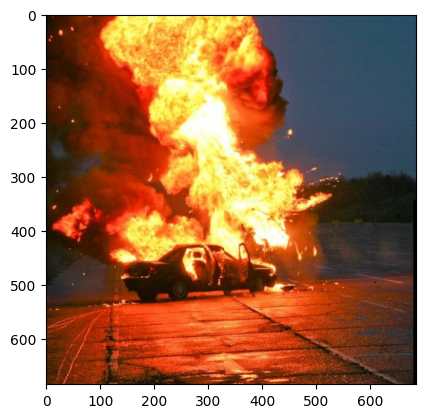

In [231]:
gabung1 = merge_image(meledak1, meledak2, orientation='H')
gabung2 = merge_image(meledak3, meledak4, orientation='H')
gabung_final = merge_image(gabung1, gabung2, orientation='v')
plt.imshow(gabung_final)
plt.show()

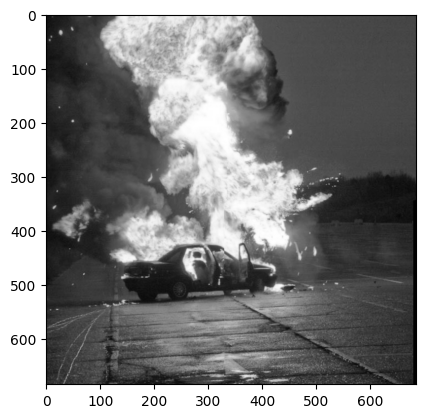

In [232]:
citra_gray = cv2.cvtColor(gabung_final, cv2.COLOR_RGB2GRAY)
plt.imshow(citra_gray, cmap='gray')

In [233]:
def ekualisasi(citra):

    if np.max(citra) <= 1.0:
        citra = citra * 255.0
        
    citra = np.round(citra).astype(int)
    
    height, width = citra.shape
    hist = np.zeros(256, dtype=int)
    
    for i in range(height):
        for j in range(width):
            nilai_pixel = citra[i, j]
            hist[nilai_pixel] += 1
            
    cdf = np.zeros(256, dtype=int)
    cdf[0] = hist[0]

    for i in range(1, 256):
        cdf[i] = cdf[i - 1] + hist[i]
        

    cdf_normal = np.round(cdf * 255 / (height * width)).astype(np.uint8)
    hasil = np.zeros_like(citra, dtype=np.uint8)
    
    # 3. Menerapkan hasil ekualisasi ke citra baru
    for i in range(height):
        for j in range(width):
            nilai_pixel_lama = citra[i, j]
            hasil[i, j] = cdf_normal[nilai_pixel_lama]
            
    return hasil


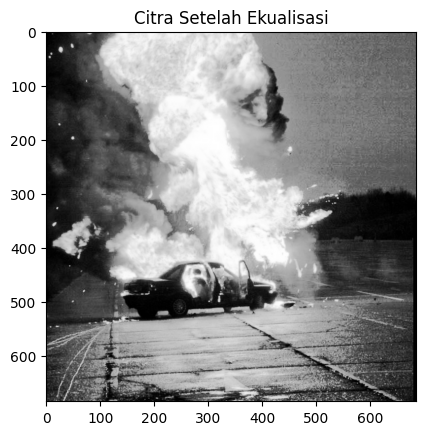

In [234]:
hasil_ekualisasi = ekualisasi(citra_gray)
plt.imshow(hasil_ekualisasi, cmap='gray')
plt.title('Citra Setelah Ekualisasi')
plt.show()

In [235]:

def buat_hist(citra):
    histogram = [0] * 256
    height = len(citra)
    width = len(citra[0]) if height > 0 else 0
    
    for i in range(height):
        for j in range(width):
            val = int(citra[i][j])
            histogram[val] += 1
            
    return histogram

def plot_histogram(histogram, title, ImgColor):
    plt.figure(figsize=(10, 5))
    plt.xlabel("Intensitas Piksel")
    plt.title(title)
    plt.ylabel("Jumlah Piksel")
    plt.bar(range(256), histogram, color=ImgColor, width=0.8)
    plt.show()


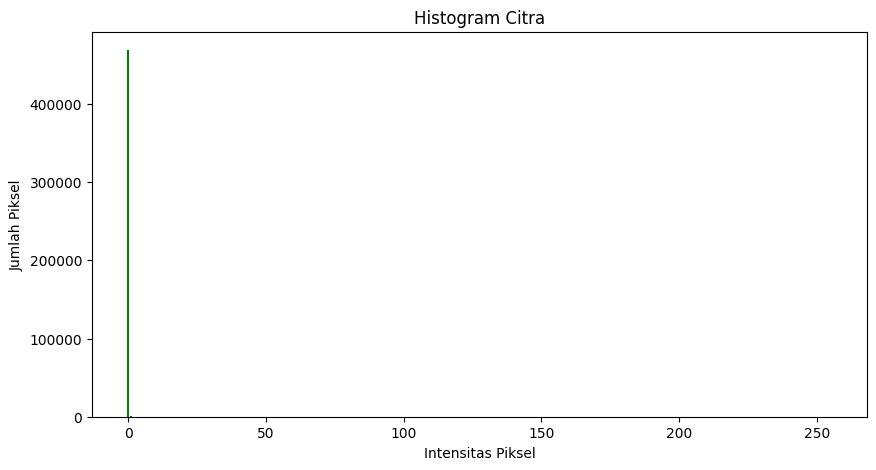

In [236]:
hist_hasil1 = buat_hist(citra_gray)
plot_histogram(hist_hasil1, "Histogram Citra", "green")

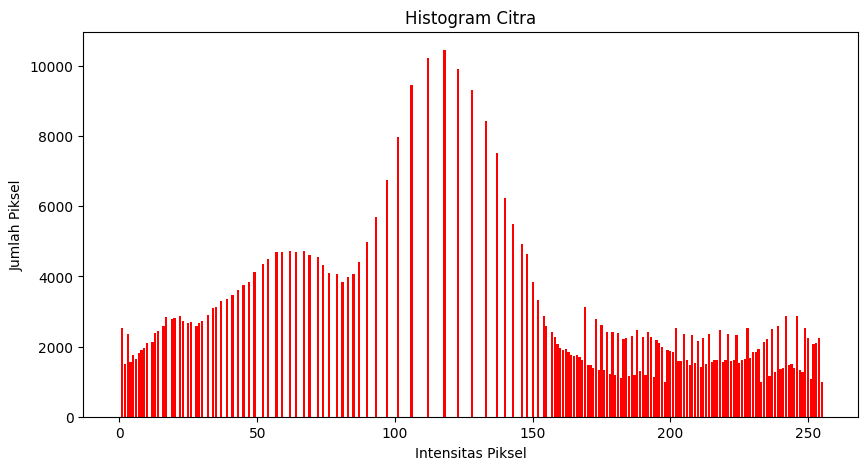

In [237]:
hist_hasil = buat_hist(hasil_ekualisasi)
plot_histogram(hist_hasil, "Histogram Citra", "red")

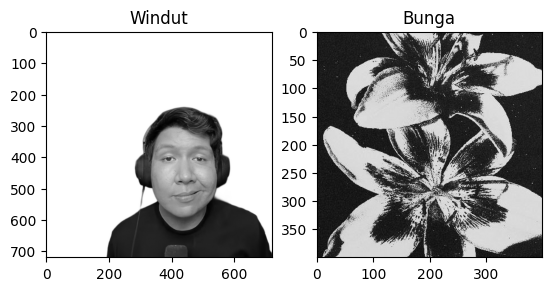

In [238]:
windah = plt.imread("Windut.png")
Bunga = plt.imread("Bunga.png")

windah_abu = cv2.cvtColor(windah, cv2.COLOR_BGR2GRAY)
bunga_abu = cv2.cvtColor(Bunga, cv2.COLOR_BGR2GRAY)

plt.subplot(1, 2, 1)
plt.imshow(windah_abu, cmap='gray')
plt.title('Windut')

plt.subplot(1, 2, 2)
plt.imshow(bunga_abu, cmap='gray')
plt.title('Bunga')

plt.show()

In [239]:

def hitung_hist_dan_cdf(citra):
    tinggi, lebar = citra.shape
    hist = np.zeros(256, dtype=int)

    for i in range(tinggi):
        for j in range(lebar):
            hist[citra[i, j]] += 1

    cdf = np.zeros(256, dtype=float)
    cdf[0] = hist[0]
    for i in range(1, 256):
        cdf[i] = cdf[i-1] + hist[i]

    max_cdf = cdf[255]
    for i in range(256):
        cdf[i] = cdf[i] / max_cdf
        
    return cdf

def spesifikasi_histogram(citra_asal, citra_target):

    cdf_asal = hitung_hist_dan_cdf(citra_asal)
    cdf_target = hitung_hist_dan_cdf(citra_target)

    map_hist = np.zeros(256, dtype=int)
    
    for i in range(256):
        selisih_terkecil = 2.0  
        index_terbaik = 0
        
        for j in range(256):
            selisih = abs(cdf_target[j] - cdf_asal[i])

            if selisih < selisih_terkecil:
                selisih_terkecil = selisih
                index_terbaik = j
                
        map_hist[i] = index_terbaik

    tinggi, lebar = citra_asal.shape
    hasil = np.zeros((tinggi, lebar), dtype=int)
    
    for i in range(tinggi):
        for j in range(lebar):
            hasil[i, j] = map_hist[citra_asal[i, j]]

    return hasil

(np.float64(-0.5), np.float64(719.5), np.float64(719.5), np.float64(-0.5))

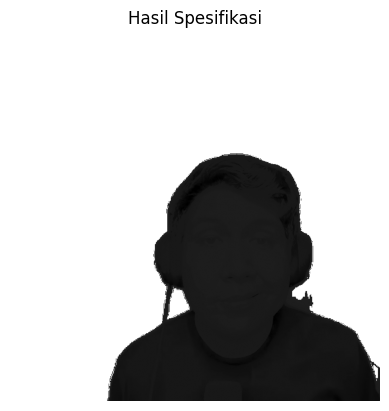

In [240]:

spesifikasi = spesifikasi_histogram((windah_abu * 255).astype(np.uint8), (bunga_abu * 255).astype(np.uint8))
plt.imshow(spesifikasi, cmap='gray')
plt.title('Hasil Spesifikasi')
plt.axis('off')

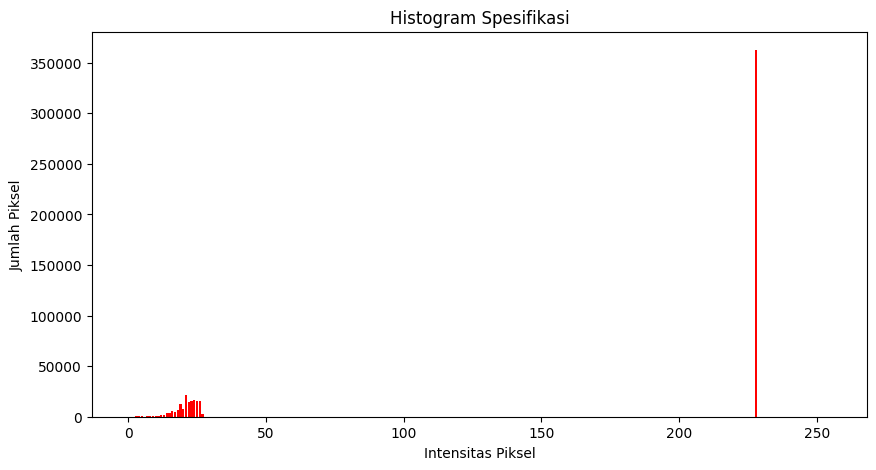

In [241]:
hist_hasil = buat_hist(spesifikasi)
plot_histogram(hist_hasil, "Histogram Spesifikasi", "red")